### Purpose: This Notebook is used to train binary classification model for Ladung VA

In [1]:
import os
from ast import literal_eval
import pandas as pd
import spacy
import re
from spacy.tokenizer import Tokenizer
import matplotlib.pyplot as plt
import dill

In [2]:
data = pd.read_csv(r'../data/PFUB_ERLASS_dataset_processed_with_geschaeftsnummer.csv')


In [3]:
data

,text,object_key,document_type,cleaned_text,data,is_pfub,is_ladung,tokenized,text_w_tags
0,4070071 967072\nAntrag auf Erlass eines Pfändu...,01.02.2022/1643724050_Doc_01022022_000000001_1...,attachment_and_transfer_order,4070071 967072\nantrag auf erlass eines pfändu...,NaN,False,False,"['antrag', 'erlass', 'pfändung', 'überweisungs...",<PHONE> <NUMBER>\nantrag auf erlass eines pfän...
1,Antrag auf Erlass eines Pfänd 070071 967072\nÜ...,01.02.2022/1643724051_Doc_01022022_000000001_1...,attachment_and_transfer_order,antrag auf erlass eines pfänd 070071 967072\nü...,NaN,False,False,"['antrag', 'erlass', 'pfänd', 'überweisungsbes...",antrag auf erlass eines pfänd <NUMBER><PHONE>\...
2,Antrag auf Erlass eines Pfändun\n4070071 96707...,01.02.2022/1643724052_Doc_01022022_000000001_1...,attachment_and_transfer_order,antrag auf erlass eines pfändun\n4070071 96707...,NaN,False,False,"['antrag', 'erlass', 'pfändun', 'überweisungsb...",antrag auf erlass eines pfändun\n<PHONE> <NUMB...
3,Antrag auf Erlass eines Pfändungs\n4 070071 96...,01.02.2022/1643724052_Doc_01022022_000000001_1...,attachment_and_transfer_order,antrag auf erlass eines pfändungs\n4 070071 96...,NaN,False,False,"['antrag', 'erlass', 'pfändung', 'überweisungs...",antrag auf erlass eines pfändungs\n<NUMBER> <N...
4,Antrag auf Erlass eines Pfändu\n4070071 967072...,01.02.2022/1643724053_Doc_01022022_000000001_1...,attachment_and_transfer_order,antrag auf erlass eines pfändu\n4070071 967072...,NaN,False,False,"['antrag', 'erlass', 'pfändu', 'überweisungsbe...",antrag auf erlass eines pfändu\n<PHONE> <NUMBE...
...,...,...,...,...,...,...,...,...,...
5026,Grover\nFriedhelm August Steiner\nBestellnumme...,NaN,mail_attachments,grover\nfriedhelm august steiner\nbestellnumme...,NaN,False,False,"['grover', 'friedhelm', 'august', 'steiner', '...",grover\nfriedhelm august steiner\nbestellnumme...
5027,Liste des créances\nCréé le: 21.08.2025\nNumér...,NaN,mail_attachments,liste des créances\ncréé le: 21.08.2025\nnumér...,NaN,False,False,"['liste', 'créance', 'créé', 'le', 'numéro', '...",liste des créances\ncréé le: <DATE>\nnuméro de...
5028,11:06\nRetour Détails de la transaction\nPDF\n...,NaN,mail_attachments,"11:06\nretour détails de la transaction\n-209,...",NaN,False,False,"['retour', 'détails', '--', '--', 'transaction...",<NUMBER>:<NUMBER>\nretour détails de la transa...
5029,e\nKLINIKUM\nKlinik für Dermatologie\nNÜRNBERG...,NaN,mail_attachments,klinikum\nklinik für dermatologie\nnürnberg\nu...,NaN,False,False,"['klinikum', 'klinik', 'dermatologie', 'nürnbe...",klinikum\nklinik für dermatologie\nnürnberg\nu...


In [4]:
data[data['document_type'] == 'mail_attachments'] # these are randomly added attachments sent to us

,text,object_key,document_type,cleaned_text,data,is_pfub,is_ladung,tokenized,text_w_tags
4025,nobilia\nnobilia-Werke J. Stickling GmbH & Co....,NaN,mail_attachments,nobilia\nnobilia-werke j. stickling gmbh & co....,NaN,False,False,"['nobilia', 'nobilia-werke', 'j.', 'stickling'...",nobilia\nnobilia-werke j. stickling gmbh & co....
4026,"Commandée livrée le\nSuivre\nsa, 07.06.2025\na...",NaN,mail_attachments,"commandée livrée le\nsuivre\nsa, 07.06.2025\na...",NaN,False,False,"['commandée', 'livrée', 'le', 'suivre', 'sa', ...","commandée livrée le\nsuivre\nsa, <DATE>\nadida..."
4027,18:10\n19\nX\nshis\nIBAN\nFR76 3000 4029 9900 ...,NaN,mail_attachments,18:10\nshis\niban\nfr76 3000 4029 9900 0105 21...,NaN,False,False,"['shi', 'iban', 'fr76', 'bnpafrpp', 'supprimer']",<NUMBER>:<NUMBER>\nshis\niban\nfr76 <NUMBER> <...
4028,KANZLEI SCHULZE-LOHNE\nKÖLN/BONN\nRA Jens Dene...,NaN,mail_attachments,kanzlei schulze-lohne\nköln/bonn\nra jens dene...,NaN,False,False,"['kanzlei', 'schulze-lohne', 'köln', 'bonn', '...",kanzlei schulze-lohne\nköln/bonn\nra jens dene...
4029,"Hey Patrick,\ndu hast zum 20.02.2021 erstmalig...",NaN,mail_attachments,"hey patrick,\ndu hast zum 20.02.2021 erstmalig...",NaN,False,False,"['hey', 'patrick', 'erstmalig', 'getsafe', 've...","hey patrick,\ndu hast zum <DATE> erstmalig ein..."
...,...,...,...,...,...,...,...,...,...
5026,Grover\nFriedhelm August Steiner\nBestellnumme...,NaN,mail_attachments,grover\nfriedhelm august steiner\nbestellnumme...,NaN,False,False,"['grover', 'friedhelm', 'august', 'steiner', '...",grover\nfriedhelm august steiner\nbestellnumme...
5027,Liste des créances\nCréé le: 21.08.2025\nNumér...,NaN,mail_attachments,liste des créances\ncréé le: 21.08.2025\nnumér...,NaN,False,False,"['liste', 'créance', 'créé', 'le', 'numéro', '...",liste des créances\ncréé le: <DATE>\nnuméro de...
5028,11:06\nRetour Détails de la transaction\nPDF\n...,NaN,mail_attachments,"11:06\nretour détails de la transaction\n-209,...",NaN,False,False,"['retour', 'détails', '--', '--', 'transaction...",<NUMBER>:<NUMBER>\nretour détails de la transa...
5029,e\nKLINIKUM\nKlinik für Dermatologie\nNÜRNBERG...,NaN,mail_attachments,klinikum\nklinik für dermatologie\nnürnberg\nu...,NaN,False,False,"['klinikum', 'klinik', 'dermatologie', 'nürnbe...",klinikum\nklinik für dermatologie\nnürnberg\nu...


In [5]:
data['document_type'].value_counts()

document_type
ladung_va                                 2101
mail_attachments                          1006
monierung_mb                               545
attachment_and_transfer_order              541
approved_seizure                           408
court_inbox                                346
approved_attachment_and_transfer_order      58
enforcement_order                           23
contradiction                                3
Name: count, dtype: int64

In [6]:
data['is_ladung'].value_counts()

is_ladung
False    2930
True     2101
Name: count, dtype: int64

In [7]:
data['document_type'].value_counts()

document_type
ladung_va                                 2101
mail_attachments                          1006
monierung_mb                               545
attachment_and_transfer_order              541
approved_seizure                           408
court_inbox                                346
approved_attachment_and_transfer_order      58
enforcement_order                           23
contradiction                                3
Name: count, dtype: int64

In [8]:
# downlaod spacy for nlp
# pip install spacy
#python -m spacy download de_core_news_md

### Tf-Idf Vectorizer with Custom Spacy Tokenizer

In [9]:
import os

notebook_dir = r'/Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks'
project_dir = os.path.dirname(notebook_dir)
print("Notebook Directory:", notebook_dir)
print("Project Directory:", project_dir)
os.chdir(project_dir)

Notebook Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks
Project Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition


In [10]:
# from spacy.tokenizer import Tokenizer
# from sklearn.feature_extraction.text import TfidfVectorizer
# # Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
# from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

# tfidf_vectorizer_experiment = TfidfVectorizer(tokenizer=ClassificationSpacyLemmaTokenizer(),
#                              max_features=200, # Original value: 200
#                              ngram_range=(1,1),
#                              decode_error='ignore',
#                              norm='l2',
#                              min_df=2,
#                              max_df=0.95,
#                              stop_words=None,
#                              lowercase=False)

# # # fit the vectorizer on the text data
# x_transformed_experiment = tfidf_vectorizer_experiment.fit_transform(data['text_w_tags'])
# tfidf_vectorizer_experiment.get_feature_names_out()
# tfidf_vectorizer_experiment.vocabulary_

In [11]:

X_text = data['text_w_tags']
y = data['is_ladung']

# train test split
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(X_train_text)}, Test set size: {len(X_test_text)}")
print(f"Train set is ladung dist: {y_train.value_counts(normalize=True)}")
print(f"Test set is ladung dist: {y_test.value_counts(normalize=True)}")


Train set size: 4024, Test set size: 1007
Train set is ladung dist: is_ladung
False    0.582505
True     0.417495
Name: proportion, dtype: float64
Test set is ladung dist: is_ladung
False    0.581927
True     0.418073
Name: proportion, dtype: float64


In [12]:
# # CREATE A CLASSIFICATION PIPELINE
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier
# import pickle
# from sklearn.feature_extraction.text import TfidfVectorizer
# # Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
# from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

# classification_pipeline = Pipeline([
#     ('tfidf', TfidfVectorizer(tokenizer=ClassificationSpacyLemmaTokenizer(),
#                              max_features=200, # Original value: 200
#                              ngram_range=(1,1),
#                              norm='l2',
#                              min_df=2,
#                              max_df=0.95,
#                              stop_words=None,
#                              lowercase=False)),
#     ('clf', RandomForestClassifier(n_estimators=100, random_state=42))

# ])

# classification_pipeline.fit(X_train_text, y_train)
# #joblib.dump(classification_pipeline, 'ladung_clf_pipeline.joblib')
# pickle.dump(classification_pipeline, open("classification_pipeline_with_mail_attachments_new.pickle", "wb"))

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
# Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

tf_idf_vectorizer = TfidfVectorizer(tokenizer=ClassificationSpacyLemmaTokenizer(),
                             max_features=200, # Original value: 200
                             ngram_range=(1,1),
                             norm='l2',
                             min_df=2,
                             max_df=0.95,
                             stop_words=None,
                             lowercase=False)

tf_idf_vectorizer.fit(X_train_text)

# save the fitted vectorizer
save_path = os.path.join(notebook_dir, "after-court/models/vectorizers/05-12-2026_tf_idf_vectorizer_v1.dill")
with open(save_path, "wb") as f:
    dill.dump(tf_idf_vectorizer, f)


/Users/melih.gorgulu/miniconda3/envs/intent-recog/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
X_train_tfidf = tf_idf_vectorizer.transform(X_train_text)
X_test_tfidf = tf_idf_vectorizer.transform(X_test_text)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_tfidf, y_train)
# save the trained model
save_path = os.path.join(notebook_dir, "after-court/models/classification/05-12-2026_rf_classifier_v1.dill")
with open(save_path, "wb") as f:
    dill.dump(rf_classifier, f)

In [14]:
y_pred = rf_classifier.predict(X_test_tfidf)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

"""
    true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}
"""

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       586
        True       1.00      1.00      1.00       421

    accuracy                           1.00      1007
   macro avg       1.00      1.00      1.00      1007
weighted avg       1.00      1.00      1.00      1007


Confusion Matrix:
[[586   0]
 [  0 421]]


'\n    true negatives is\n    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is\n    :math:`C_{1,1}` and false positives is :math:`C_{0,1}\n'

#### Check token importances

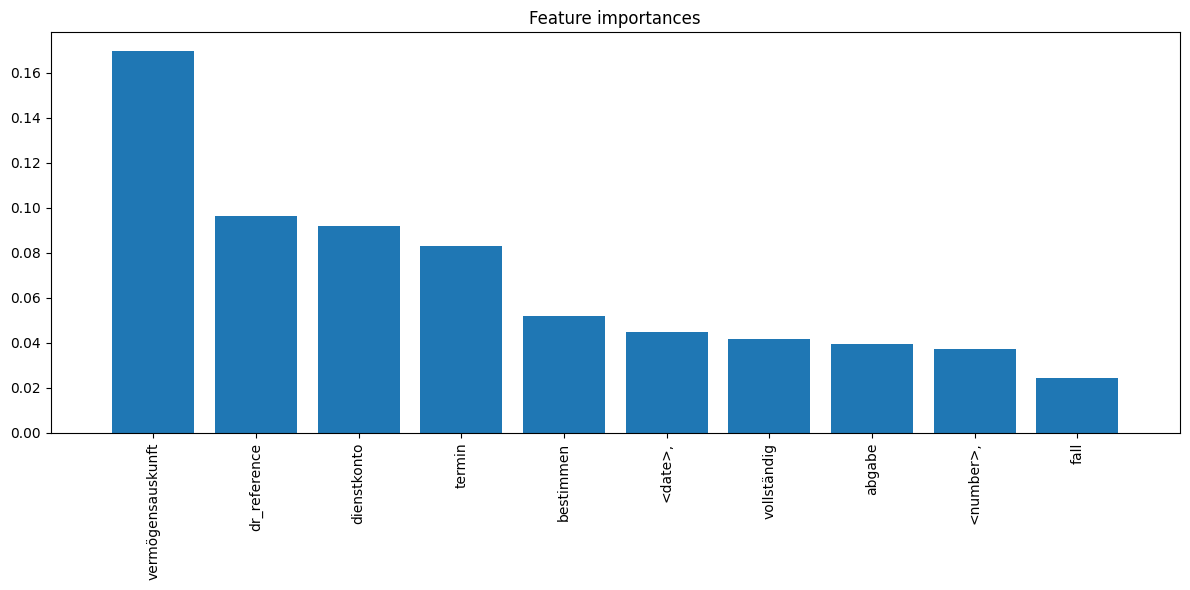

In [16]:
# plot feature importance of the random forest classifier
import numpy as np
feature_names = tf_idf_vectorizer.get_feature_names_out()
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
# Plot the feature importances of the forest
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices][:10], rotation=90)
plt.xlim([-1, 10])
plt.tight_layout()
plt.show()